# Análisis de los datos

Se cubren los siguientes puntos:  
- Número de registros y estructura general  
- Valores faltantes
- Valores únicos por variable
- Duplicados exactos
- Formatos inconsistentes
- Graficas del diagnóstico
- Problemas potenciales

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import re

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

In [3]:
df = pd.read_csv('../data/processed/centros_educativos_gt.csv', dtype=str, encoding="utf-8", header=1)
df.head(5)


,CODIGO,DISTRITO,DEPARTAMENTO,MUNICIPIO,ESTABLECIMIENTO,DIRECCION,TELEFONO,SUPERVISOR,DIRECTOR,NIVEL,SECTOR,AREA,STATUS,MODALIDAD,JORNADA,PLAN,DEPARTAMENTAL
0,16-01-0026-45,16-01-0923,ALTA VERAPAZ,COBAN,COLEGIO PARTICULAR MIXTO IMPERIAL,5A. CALLE 1-98 ZONA 3,57101061,EFRAIN CAAL CUC,MYNOR GUSTAVO IPIÑA ESPAÑA,BASICO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,DOBLE,FIN DE SEMANA,ALTA VERAPAZ
1,16-01-0135-45,16-01-0925,ALTA VERAPAZ,COBAN,INEB ADSCRITO A INSTITUTO 'EMILIO ROSALES PONCE',3A AVE 6-23 ZONA 11,54457786,NORA LILIANA FIGUEROA HERNÁNDEZ,VICTOR HUGO DOMÍNGUEZ REYES,BASICO,OFICIAL,URBANA,ABIERTA,BILINGUE,MATUTINA,DIARIO(REGULAR),ALTA VERAPAZ
2,16-01-0136-45,16-01-0923,ALTA VERAPAZ,COBAN,INEB,6A AVE 1-15 ZONA 4,55541910,EFRAIN CAAL CUC,MAYRA PAULINA LAZARO CABRERA,BASICO,OFICIAL,URBANA,ABIERTA,MONOLINGUE,MATUTINA,DIARIO(REGULAR),ALTA VERAPAZ
3,16-01-0137-45,16-006,ALTA VERAPAZ,COBAN,INSTITUTO MIXTO NOCTURNO FRANCISCO MARROQUIN,6A AVE 1-15 ZONA 4,NaN,JORGE EDUARDO PAQUE LAZARO,NaN,BASICO,PRIVADO,URBANA,CERRADA DEFINITIVAMENTE,MONOLINGUE,NOCTURNA,DIARIO(REGULAR),ALTA VERAPAZ
4,16-01-0138-45,16-01-0926,ALTA VERAPAZ,COBAN,COLEGIO COBAN,"KM.2 SALIDA A SAN JUAN CHAMELCO, ZONA 8",77945104,JOSE ARTURO CHOC CHEN,GUSTAVO ADOLFO SIERRA POP,BASICO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,MATUTINA,DIARIO(REGULAR),ALTA VERAPAZ


## Estructura del dataset

In [4]:
filas, columnas = df.shape

print(f"Número de registros del dataset: {filas} \n")
print(f"Número de variables del dataset: {columnas} \n")
print(f"Nombre de las variables: {list(df.columns)} \n")

print(f"Tipo de datos por variable:\n{df.dtypes} \n")

print(f"Departamentos: {df['DEPARTAMENTO'].nunique()} \n")
print(f"Municipios: {df['MUNICIPIO'].nunique()} \n")
print(f"Cantidad de establecimientos por departamento: {df['DEPARTAMENTO'].value_counts()} \n")


Número de registros del dataset: 101224 

Número de variables del dataset: 17 

Nombre de las variables: ['CODIGO', 'DISTRITO', 'DEPARTAMENTO', 'MUNICIPIO', 'ESTABLECIMIENTO', 'DIRECCION', 'TELEFONO', 'SUPERVISOR', 'DIRECTOR', 'NIVEL', 'SECTOR', 'AREA', 'STATUS', 'MODALIDAD', 'JORNADA', 'PLAN', 'DEPARTAMENTAL'] 

Tipo de datos por variable:
CODIGO             object
DISTRITO           object
DEPARTAMENTO       object
MUNICIPIO          object
ESTABLECIMIENTO    object
DIRECCION          object
TELEFONO           object
SUPERVISOR         object
DIRECTOR           object
NIVEL              object
SECTOR             object
AREA               object
STATUS             object
MODALIDAD          object
JORNADA            object
PLAN               object
DEPARTAMENTAL      object
dtype: object 

Departamentos: 24 

Municipios: 358 

Cantidad de establecimientos por departamento: DEPARTAMENTO
ALTA VERAPAZ      11990
GUATEMALA         10058
HUEHUETENANGO      8165
CIUDAD CAPITAL     7791
QUICH

## Valores faltantes

Se revisan dos tipos de valores faltantes:
- **Nulos reales:** Celdas faltantes en el CSV.
- **Placeholders:** Representación de datos faltantes pero no estan vacíos.

In [5]:
PLACEHOLDERS_NULOS = ["--", "-", "N/A", "NA", "S/N", "S/D", "", " ", "NINGUNO", "NO TIENE"]

def cuenta_placeholders(serie):
    return serie.dropna().astype(str).str.strip().str.upper().isin(PLACEHOLDERS_NULOS).sum()

resumen_na = pd.DataFrame({
    "n_nulos_reales": df.isna().sum(),
    "n_placeholders": [cuenta_placeholders(df[c]) for c in df.columns],
})
resumen_na["n_faltantes_total"] = resumen_na["n_nulos_reales"] + resumen_na["n_placeholders"]
resumen_na["pct_faltantes_total"] = (resumen_na["n_faltantes_total"] / len(df) * 100).round(2)
resumen_na = resumen_na.sort_values("pct_faltantes_total", ascending=False)
resumen_na


,n_nulos_reales,n_placeholders,n_faltantes_total,pct_faltantes_total
TELEFONO,31457,0,31457,31.08
DIRECTOR,31006,437,31443,31.06
SUPERVISOR,12610,0,12610,12.46
DISTRITO,12602,0,12602,12.45
DIRECCION,966,3,969,0.96
ESTABLECIMIENTO,16,0,16,0.02
CODIGO,0,0,0,0.00
MUNICIPIO,0,0,0,0.00
DEPARTAMENTO,0,0,0,0.00
NIVEL,0,0,0,0.00


## Valores Únicos


In [6]:
valores_unicos = pd.DataFrame({
    "valores_unicos" : df.nunique(),
    "Porcentaje: ": (df.nunique() / len(df) * 100).round(2)
})
valores_unicos

,valores_unicos,Porcentaje:
CODIGO,92363,91.25
DISTRITO,2275,2.25
DEPARTAMENTO,24,0.02
MUNICIPIO,358,0.35
ESTABLECIMIENTO,21538,21.28
DIRECCION,42492,41.98
TELEFONO,36465,36.02
SUPERVISOR,1631,1.61
DIRECTOR,35633,35.20
NIVEL,7,0.01


## Valores Duplicados exactos
Se analiza los registros duplicados analizando:
- Filas completamente duplicadas
- Filas duplicadas sin tomar en cuenta el `CODIGO` para revisar si algun establecimiento fue registrado mas de una vez
- Posibles establecimientos repetidos donde los datos mas relevantes para identificar un establecimiento estan repetidos. 

In [7]:
print(f"Filas completamente duplicadas: {df.duplicated().sum()}")

print(f"\nFilas duplicadas sin considerar codigo: {df.drop(columns=['CODIGO']).duplicated().sum()}")

codigo_duplicado = df[df["CODIGO"].duplicated(keep=False)]

print(f"\nCódigos distintos repetidos: {codigo_duplicado['CODIGO'].nunique()}")
print(f"Filas involucradas: {len(codigo_duplicado)}")

if len(codigo_duplicado) > 0:
    display(codigo_duplicado.sort_values("CODIGO"))

establecimientos_repetidos =df[df.duplicated(
    subset=["ESTABLECIMIENTO","MUNICIPIO","DEPARTAMENTO","DIRECCION"],
    keep=False
)]

print("Posibles establecimientos repetidos")
display(establecimientos_repetidos.sort_values(
    ["ESTABLECIMIENTO","MUNICIPIO"]
))

Filas completamente duplicadas: 8861

Filas duplicadas sin considerar codigo: 9221

Códigos distintos repetidos: 8682
Filas involucradas: 17543


,CODIGO,DISTRITO,DEPARTAMENTO,MUNICIPIO,ESTABLECIMIENTO,DIRECCION,TELEFONO,SUPERVISOR,DIRECTOR,NIVEL,SECTOR,AREA,STATUS,MODALIDAD,JORNADA,PLAN,DEPARTAMENTAL
28243,00-01-0147-44,01-402,CIUDAD CAPITAL,ZONA 1,EOPA 'CENTRO DE RECUPERACION DE LISIADOS FISICOS',13 CALLE 0-18,22325742,CARLOS HUMBERTO GONZALEZ DE LEON,NaN,PRIMARIA DE ADULTOS,OFICIAL,URBANA,CERRADA TEMPORALMENTE,MONOLINGUE,MATUTINA,DIARIO(REGULAR),GUATEMALA NORTE
28444,00-01-0147-44,01-402,CIUDAD CAPITAL,ZONA 1,EOPA 'CENTRO DE RECUPERACION DE LISIADOS FISICOS',13 CALLE 0-18,22325742,CARLOS HUMBERTO GONZALEZ DE LEON,NaN,PRIMARIA DE ADULTOS,OFICIAL,URBANA,CERRADA TEMPORALMENTE,MONOLINGUE,MATUTINA,DIARIO(REGULAR),GUATEMALA NORTE
28244,00-01-0148-44,01-402,CIUDAD CAPITAL,ZONA 1,EOPA NO.16 'LISANDRO SANDOVAL',7A AVE. 13-73,22537856,CARLOS HUMBERTO GONZALEZ DE LEON,NaN,PRIMARIA DE ADULTOS,OFICIAL,URBANA,CERRADA TEMPORALMENTE,MONOLINGUE,NOCTURNA,DIARIO(REGULAR),GUATEMALA NORTE
28445,00-01-0148-44,01-402,CIUDAD CAPITAL,ZONA 1,EOPA NO.16 'LISANDRO SANDOVAL',7A AVE. 13-73,22537856,CARLOS HUMBERTO GONZALEZ DE LEON,NaN,PRIMARIA DE ADULTOS,OFICIAL,URBANA,CERRADA TEMPORALMENTE,MONOLINGUE,NOCTURNA,DIARIO(REGULAR),GUATEMALA NORTE
28245,00-01-0149-44,01-01-0037,CIUDAD CAPITAL,ZONA 1,EOPA NO.26 JOSE JOAQUIN PARDO,3 AV. C 24-24 AV. EL FERROCARRIL,57123025,CARLOS HUMBERTO GONZALEZ DE LEON,JESSICA LIZETH PENELEU LÓPEZ,PRIMARIA DE ADULTOS,OFICIAL,URBANA,ABIERTA,MONOLINGUE,NOCTURNA,DIARIO(REGULAR),GUATEMALA NORTE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56322,CODIGO,DISTRITO,DEPARTAMENTO,MUNICIPIO,ESTABLECIMIENTO,DIRECCION,TELEFONO,SUPERVISOR,DIRECTOR,NIVEL,SECTOR,AREA,STATUS,MODALIDAD,JORNADA,PLAN,DEPARTAMENTAL
56889,CODIGO,DISTRITO,DEPARTAMENTO,MUNICIPIO,ESTABLECIMIENTO,DIRECCION,TELEFONO,SUPERVISOR,DIRECTOR,NIVEL,SECTOR,AREA,STATUS,MODALIDAD,JORNADA,PLAN,DEPARTAMENTAL
99107,CODIGO,DISTRITO,DEPARTAMENTO,MUNICIPIO,ESTABLECIMIENTO,DIRECCION,TELEFONO,SUPERVISOR,DIRECTOR,NIVEL,SECTOR,AREA,STATUS,MODALIDAD,JORNADA,PLAN,DEPARTAMENTAL
55432,CODIGO,DISTRITO,DEPARTAMENTO,MUNICIPIO,ESTABLECIMIENTO,DIRECCION,TELEFONO,SUPERVISOR,DIRECTOR,NIVEL,SECTOR,AREA,STATUS,MODALIDAD,JORNADA,PLAN,DEPARTAMENTAL


Posibles establecimientos repetidos


,CODIGO,DISTRITO,DEPARTAMENTO,MUNICIPIO,ESTABLECIMIENTO,DIRECCION,TELEFONO,SUPERVISOR,DIRECTOR,NIVEL,SECTOR,AREA,STATUS,MODALIDAD,JORNADA,PLAN,DEPARTAMENTAL
22126,00-11-0090-45,01-640,CIUDAD CAPITAL,ZONA 11,"""CEEX - SECRETARIA DE BIENESTAR SOCIAL DE LA P...",32A. CALLE 9-34,42209206,ELISEO DANIEL ALVAREZ NATARENO,SUSAN GLORIANA SALAZAR FIGUEROA,BASICO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,SIN JORNADA,SEMIPRESENCIAL (DOS DÍAS A LA SEMANA),GUATEMALA SUR
24392,00-11-0091-46,01-640,CIUDAD CAPITAL,ZONA 11,"""CEEX - SECRETARIA DE BIENESTAR SOCIAL DE LA P...",32A. CALLE 9-34,42209306,ELISEO DANIEL ALVAREZ NATARENO,SUSAN GLORIANA SALAZAR FIGUEROA,DIVERSIFICADO,PRIVADO,URBANA,ABIERTA,MONOLINGUE,DOBLE,SEMIPRESENCIAL,GUATEMALA SUR
61524,17-05-0211-46,17-05-0034,PETEN,LA LIBERTAD,"""CENTRO DE EDUCACION INTEGRAL EL NARANJO""",ALDEA EL NARANJO,57283598,ARIEL ESAU PELAEZ,MIRIÁN VIRGINIA MARTÍNEZ CANTÉ,DIVERSIFICADO,PRIVADO,RURAL,ABIERTA,MONOLINGUE,VESPERTINA,DIARIO(REGULAR),PETÉN
61542,17-05-0260-46,17-05-0034,PETEN,LA LIBERTAD,"""CENTRO DE EDUCACION INTEGRAL EL NARANJO""",ALDEA EL NARANJO,57283598,ARIEL ESAU PELAEZ,MIRIÁN VIRGINIA MARTÍNEZ CANTÉ,DIVERSIFICADO,PRIVADO,RURAL,ABIERTA,BILINGUE,DOBLE,FIN DE SEMANA,PETÉN
61562,17-05-0319-46,17-05-0034,PETEN,LA LIBERTAD,"""CENTRO DE EDUCACION INTEGRAL EL NARANJO""",ALDEA EL NARANJO,53663885,ARIEL ESAU PELAEZ,MIRIÁN VIRGINIA MARTÍNEZ CANTÉ,DIVERSIFICADO,PRIVADO,RURAL,ABIERTA,MONOLINGUE,MATUTINA,DIARIO(REGULAR),PETÉN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33451,05-01-0702-44,NaN,ESCUINTLA,ESCUINTLA,NaN,"ESCUELA TIPO FEDERACION 'JOSE MARTI', 4A. AV. ...",NaN,NaN,NaN,PRIMARIA DE ADULTOS,PRIVADO,URBANA,CERRADA DEFINITIVAMENTE,MONOLINGUE,INTERMEDIA,DIARIO(REGULAR),ESCUINTLA
90189,06-06-1622-41,NaN,SANTA ROSA,ORATORIO,NaN,NaN,NaN,NaN,NaN,PREPRIMARIA BILINGUE,OFICIAL,URBANA,CERRADA DEFINITIVAMENTE,BILINGUE,MATUTINA,DIARIO(REGULAR),SANTA ROSA
91140,06-06-1622-41,NaN,SANTA ROSA,ORATORIO,NaN,NaN,NaN,NaN,NaN,PREPRIMARIA BILINGUE,OFICIAL,URBANA,CERRADA DEFINITIVAMENTE,BILINGUE,MATUTINA,DIARIO(REGULAR),SANTA ROSA
70070,09-16-0920-44,09-,QUETZALTENANGO,ZUNIL,NaN,ALDEA LA CALERA,NaN,WILSON RANFERI SIGUENZA LOPEZ,NO REGISTRADO,PRIMARIA DE ADULTOS,OFICIAL,RURAL,CERRADA DEFINITIVAMENTE,MONOLINGUE,VESPERTINA,DIARIO(REGULAR),QUETZALTENANGO


## Formatos inconsistentes

Se revisan los patrones típicos:
- Espacios extra (al inicio/final o dobles internos)
- Formato de `CODIGO` (se espera `DD-DD-NNNN-NN`)
- Formato de `DISTRITO` (se observan al menos dos patrones distintos en los datos de ejemplo)
- Formato de `TELEFONO` (se espera 8 dígitos numéricos)
- Inconsistencias de mayúsculas/minúsculas en columnas categóricas
- Caracteres especiales embebidos en nombres de establecimientos (comillas, siglas entre guiones)
- Coherencia entre `DEPARTAMENTO` y `DEPARTAMENTAL` (deberían ser siempre iguales)

In [8]:
hallazgos = []

#espacios 
for col in df.columns:
    n = df[col].apply(lambda x: isinstance(x, str) and x != x.strip()).sum()
    if n > 0: 
        hallazgos.append((col, "espacios al inicio o final", n))

for col in df.columns:
    n = df[col].astype(str).str.contains(r"\s{2,}", regex=True, na=False).sum()
    if n > 0:
        hallazgos.append((col, "espacios dobles", n))

#formato codigo
patron_codigo = re.compile(r"^\d{2}-\d{2}-\d{4}-\d{2}$")
codigo_invalido = (~df["CODIGO"].astype(str).str.match(patron_codigo).sum())
hallazgos.append(("CODIGO", "formato inválido", codigo_invalido))

#formato distrito
def clasifica_distrito(x):
    if pd.isna(x):
        return "FALTANTE"
    if re.match(r"^\d{2}-\d{3}$", x):
        return "DD-NNN"
    if re.match(r"^\d{2}-\d{2}-\d{4}$", x):
        return "DD-DD-NNNN"
    return "OTRO"

patrones_distrito = df["DISTRITO"].apply(clasifica_distrito)
print("Patrones distintos encontrados en DISTRITO:")
print(patrones_distrito.value_counts())
hallazgos.append(("DISTRITO", "múltiples patrones de formato (ver detalle arriba)", patrones_distrito.nunique()))

#formato telefono
patron_telefono = re.compile(r"^\d{8}$")
telefono = df["TELEFONO"].dropna().astype(str).str.strip()
telefono = telefono[telefono != ""]
telefono_invalido = (~telefono.str.match(patron_telefono).sum())
hallazgos.append(("TELEFONO", "formato inválido", telefono_invalido))

con_letras = telefono[telefono.str.contains(r"[A-Za-z]", regex=True)]
print(f"\nTeléfonos con letras: {len(con_letras)}")
if len(con_letras) > 0:
    display(con_letras.head(10))

#registros con NIVEL diferente a DIVERSIFICADO
niveles_no_esperados = df[df["NIVEL"].astype(str).str.strip().str.upper() != "DIVERSIFICADO"]
print(f"Registros con NIVEL distinto de DIVERSIFICADO: {len(niveles_no_esperados)}")
if len(niveles_no_esperados) > 0:
    display(niveles_no_esperados["NIVEL"].value_counts())

#verificacion de mayusculas
for col in ["DEPARTAMENTO", "MUNICIPIO", "SECTOR", "AREA", "STATUS", "MODALIDAD", "JORNADA", "PLAN"]:
    valores = df[col].dropna().astype(str)
    no_mayusculas = (valores != valores.str.upper()).sum()
    if no_mayusculas > 0:
        hallazgos.append((col, "no estan en mayuscula", no_mayusculas))

#caracteres especiales
n_comillas = df["ESTABLECIMIENTO"].astype(str).str.contains(r'"').sum()
hallazgos.append(("ESTABLECIMIENTO", "contiene comillas dobles", n_comillas))

n_guion_final = df["ESTABLECIMIENTO"].astype(str).str.contains(r"-\w+-\s*$").sum()
hallazgos.append(("ESTABLECIMIENTO", "termina en sigla entre guiones, ej. -IIAV-", n_guion_final))


#match entre DEPARTAMENTO y DEPARTAMENTAL
n_mismatch = (df["DEPARTAMENTO"].astype(str).str.strip() != df["DEPARTAMENTAL"].astype(str).str.strip()).sum()
hallazgos.append(("DEPARTAMENTO vs DEPARTAMENTAL", "no coinciden entre sí", n_mismatch))

hallazgos_df = pd.DataFrame(hallazgos, columns=["Variable", "Inconsistencia", "Registros_afectados"])
hallazgos_df = hallazgos_df[hallazgos_df["Registros_afectados"] > 0].sort_values("Registros_afectados", ascending=False)
hallazgos_df




Patrones distintos encontrados en DISTRITO:
DISTRITO
DD-DD-NNNN    57300
DD-NNN        31061
FALTANTE      12602
OTRO            261
Name: count, dtype: int64

Teléfonos con letras: 238


761                     TELEFONO
1237                    TELEFONO
1968     9521808, 8922980 (CEL.)
2264                    TELEFONO
4579                    TELEFONO
9594                    TELEFONO
9638                    TELEFONO
11953                   TELEFONO
11997                   TELEFONO
12311                   TELEFONO
Name: TELEFONO, dtype: object

Registros con NIVEL distinto de DIVERSIFICADO: 89356


NIVEL
PRIMARIA                34650
PARVULOS                21615
BASICO                  15548
PREPRIMARIA BILINGUE    15368
PRIMARIA DE ADULTOS      1994
NIVEL                     181
Name: count, dtype: int64

,Variable,Inconsistencia,Registros_afectados
5,DEPARTAMENTO vs DEPARTAMENTAL,no coinciden entre sí,41212
3,ESTABLECIMIENTO,contiene comillas dobles,6169
4,ESTABLECIMIENTO,"termina en sigla entre guiones, ej. -IIAV-",3882
1,DISTRITO,múltiples patrones de formato (ver detalle arr...,4


## Graficas del diagnostico


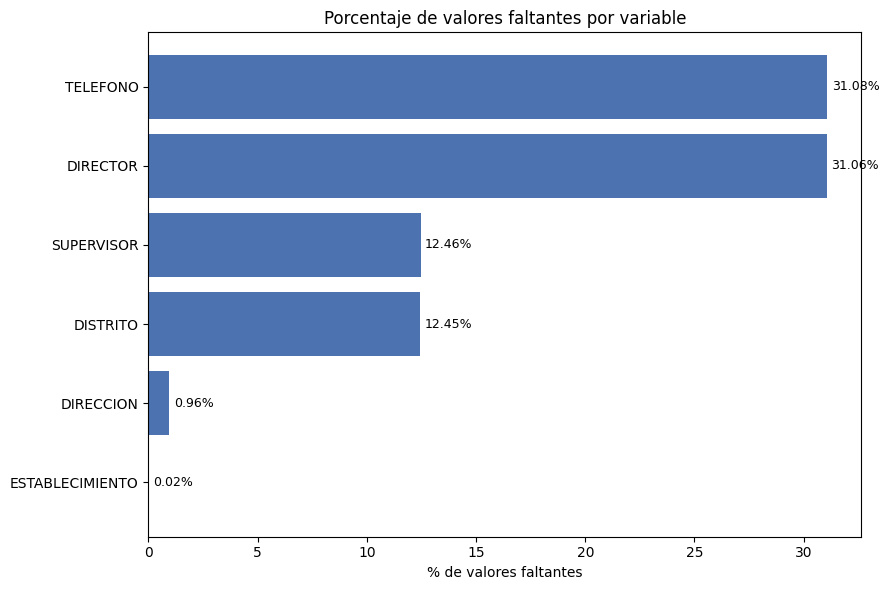

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
resumen_na_plot = resumen_na[resumen_na["pct_faltantes_total"] > 0].sort_values("pct_faltantes_total")
ax.barh(resumen_na_plot.index, resumen_na_plot["pct_faltantes_total"], color="#4C72B0")
ax.set_xlabel("% de valores faltantes")
ax.set_title("Porcentaje de valores faltantes por variable")
for i, v in enumerate(resumen_na_plot["pct_faltantes_total"]):
    ax.text(v + 0.2, i, f"{v}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

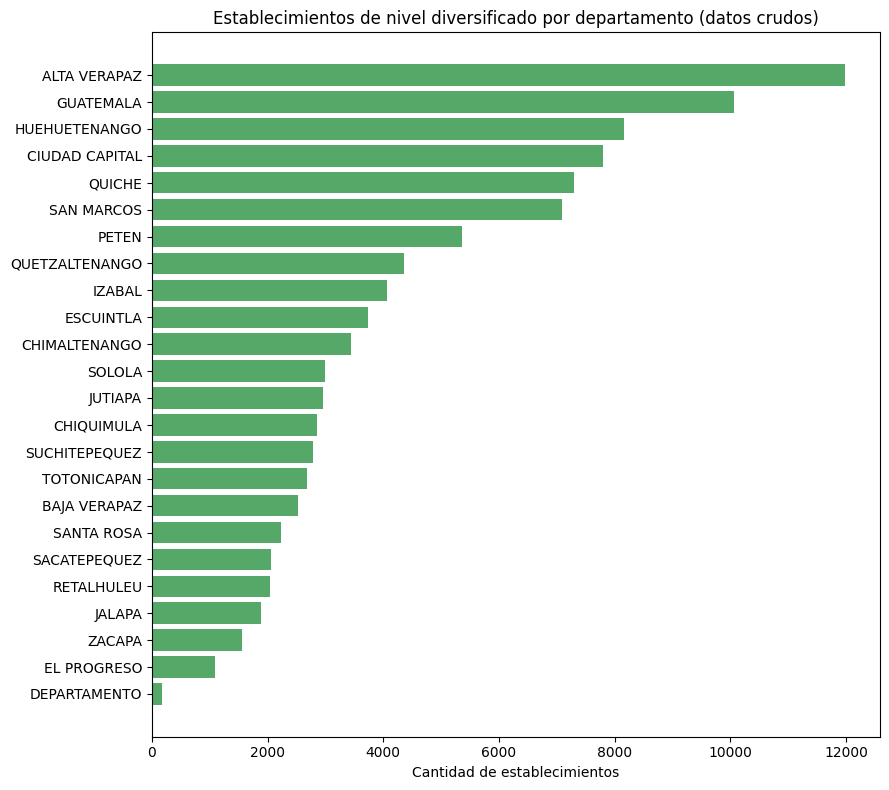

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))
conteo_depto = df["DEPARTAMENTO"].value_counts().sort_values()
ax.barh(conteo_depto.index, conteo_depto.values, color="#55A868")
ax.set_xlabel("Cantidad de establecimientos")
ax.set_title("Establecimientos de nivel diversificado por departamento (datos crudos)")
plt.tight_layout()
plt.show()

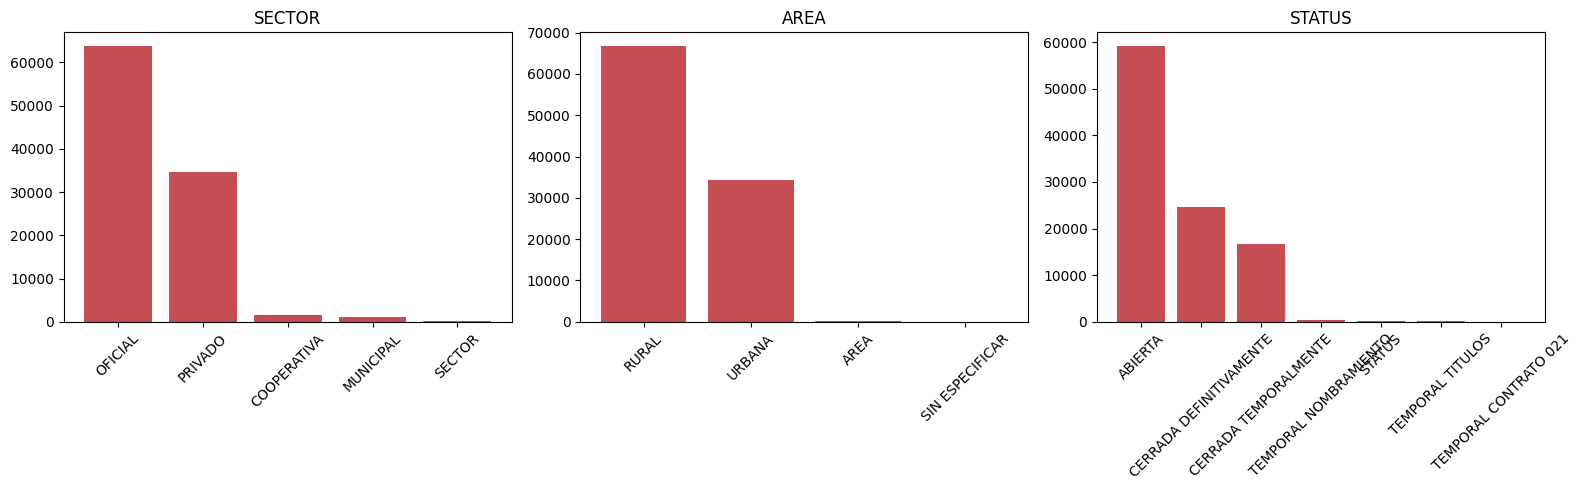

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["SECTOR", "AREA", "STATUS"]):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color="#C44E52")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

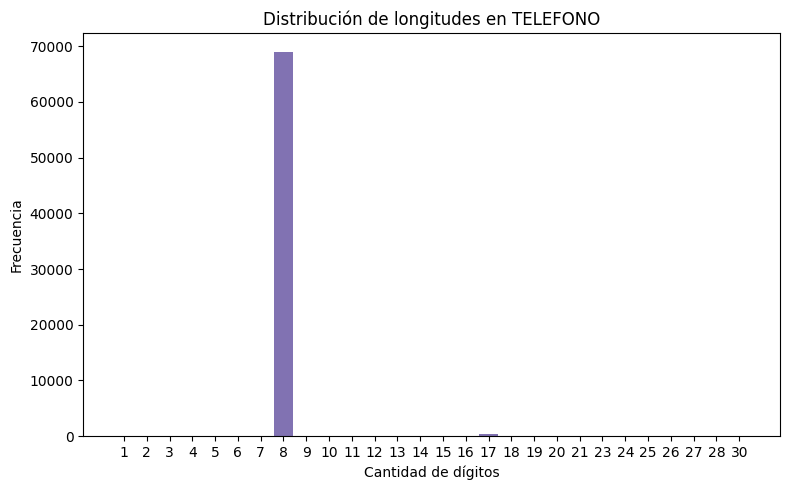

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
longitudes = telefono.str.len().value_counts().sort_index()
ax.bar(longitudes.index.astype(str), longitudes.values, color="#8172B2")
ax.set_xlabel("Cantidad de dígitos")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de longitudes en TELEFONO")
plt.tight_layout()
plt.show()

## Conclusiones y problemas potenciales de la calidad de datos

**Hallazgos principales:**
- Entre las filas que salieron duplicadas se puede observar que es el encabezado del dataset, pues como se concatenaron varios CSV, se repite. Esto afecta a los registros que tienen letras o caracteres fuera del formato que se espera. 
- `DEPARTAMENTO` vs `DEPARTAMENTAL` no coinciden en ~6,116 registros.** Debe decidirse cuál variable es la fuente de verdad (probablemente `DEPARTAMENTO`, más granular) y si `DEPARTAMENTAL` debe eliminarse.
- Valores faltantes concentrados en pocas variables: `DIRECTOR` (15.06%), `TELEFONO` (7.96%), `SUPERVISOR` (4.50%) y `DISTRITO` (4.47%). El resto de variables no presenta faltantes relevantes.
- `ESTABLECIMIENTO` con ruido de texto: comillas dobles embebidas (2,228 registros) y siglas finales entre guiones (265 registros) que deberían normalizarse.
- Posibles duplicados parciales (mismo establecimiento/municipio/departamento/dirección con distinto `CODIGO`) sugieren que el mismo centro educativo fue registrado más de una vez, posiblemente por trámites o jornadas distintas.